ℹ️ Classes du modèle : ['couple', 'femelle', 'male']

############################################################
🔍 ÉVALUATION DU SPLIT : TRAIN
############################################################
📂 Images trouvées : 242
   Classes détectées dans le dossier : ['femelle', 'male']


/tmp/ipykernel_31603/2211854528.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(WEIGHTS_PATH, map_location=DEVICE)



📊 RÉSULTATS POUR TRAIN
              precision    recall  f1-score   support

      couple     0.0000    0.0000    0.0000         0
     femelle     0.6618    0.3462    0.4545       130
        male     0.5238    0.0982    0.1654       112

    accuracy                         0.2314       242
   macro avg     0.3952    0.1481    0.2067       242
weighted avg     0.5979    0.2314    0.3207       242



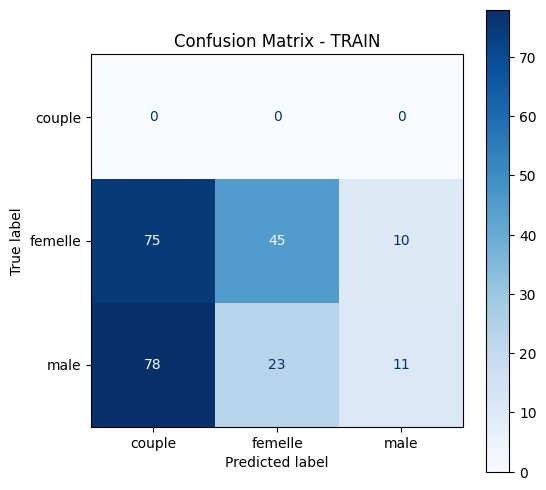

❌ Nombre d'erreurs : 186 / 242
   Exemples d'erreurs :
   - img_A_00007_crop0.png : Prédit couple vs Réel femelle
   - img_A_00008_crop0.png : Prédit couple vs Réel femelle
   - img_A_00010_crop0.png : Prédit couple vs Réel femelle

############################################################
🔍 ÉVALUATION DU SPLIT : VAL
############################################################
📂 Images trouvées : 33
   Classes détectées dans le dossier : ['femelle', 'male']

📊 RÉSULTATS POUR VAL
              precision    recall  f1-score   support

      couple     0.0000    0.0000    0.0000         0
     femelle     0.5714    0.2222    0.3200        18
        male     0.5000    0.0667    0.1176        15

    accuracy                         0.1515        33
   macro avg     0.3571    0.0963    0.1459        33
weighted avg     0.5390    0.1515    0.2280        33



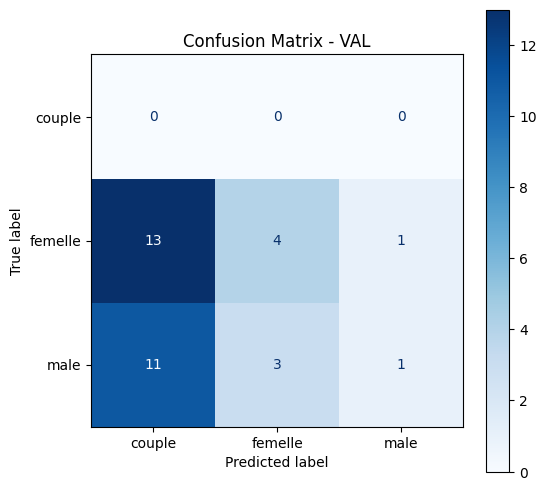

❌ Nombre d'erreurs : 28 / 33
   Exemples d'erreurs :
   - img_A_00005_crop0.png : Prédit couple vs Réel femelle
   - img_A_00009_crop0.png : Prédit couple vs Réel femelle
   - img_A_00018_crop0.png : Prédit couple vs Réel femelle


In [1]:
import os
import json
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ---------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------
ROOT_PROJET = "get_project_root()"
DATA_ROOT = os.path.join(ROOT_PROJET, "data/03_inprocess/dataset/dataset/")
WEIGHTS_PATH = os.path.join(ROOT_PROJET, "outputs/mobilenet_v3_mfc_3classes_512/best_model.pth")
META_PATH = os.path.join(ROOT_PROJET, "outputs/mobilenet_v3_mfc_3classes_512/best_meta.json")

BATCH_SIZE = 32
CROP_SIZE = 512
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------
# 2. CHARGEMENT MODÈLE (Une seule fois)
# ---------------------------------------------------------
def build_mobilenetv3(num_classes: int):
    m = models.mobilenet_v3_large(weights=None)
    in_feats = m.classifier[0].in_features
    m.classifier = nn.Sequential(
        nn.Linear(in_feats, 512),
        nn.LayerNorm(512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes),
    )
    return m

# Chargement Meta
assert os.path.exists(META_PATH), "Meta JSON introuvable"
with open(META_PATH, "r") as f:
    meta_clf = json.load(f)

model_class_names = meta_clf["class_names"]  # ex: ["couple", "femelle", "male"]
NUM_CLASSES = len(model_class_names)
model_name_to_idx = {name: i for i, name in enumerate(model_class_names)}

print(f"ℹ️ Classes du modèle : {model_class_names}")

# Chargement Modèle
model = build_mobilenetv3(NUM_CLASSES).to(DEVICE)
state = torch.load(WEIGHTS_PATH, map_location=DEVICE)
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
model.load_state_dict(state, strict=True)
model.eval()

# Preprocess standard
preprocess = transforms.Compose([
    transforms.Resize((CROP_SIZE, CROP_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---------------------------------------------------------
# 3. FONCTION D'ÉVALUATION GÉNÉRIQUE
# ---------------------------------------------------------
def evaluate_split(split_name):
    print("\n" + "#"*60)
    print(f"🔍 ÉVALUATION DU SPLIT : {split_name.upper()}")
    print("#"*60)

    dataset_dir = os.path.join(DATA_ROOT, split_name)
    if not os.path.exists(dataset_dir):
        print(f"⚠️ Dossier introuvable : {dataset_dir}")
        return

    dataset = datasets.ImageFolder(root=dataset_dir, transform=preprocess)
    print(f"📂 Images trouvées : {len(dataset)}")
    
    # --- Mapping Dynamique ---
    dataset_class_to_idx = dataset.class_to_idx
    translation_map = {}
    
    print(f"   Classes détectées dans le dossier : {list(dataset_class_to_idx.keys())}")

    for class_name, folder_idx in dataset_class_to_idx.items():
        if class_name in model_name_to_idx:
            model_idx = model_name_to_idx[class_name]
            translation_map[folder_idx] = model_idx
        else:
            print(f"⚠️ Classe '{class_name}' ignorée (inconnue du modèle).")

    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    all_preds = []
    all_labels = []
    mistakes = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(dataloader):
            images = images.to(DEVICE)
            # Traduction des labels
            labels_model = torch.tensor([translation_map[l.item()] for l in labels], device=DEVICE)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_model.cpu().numpy())
            
            # Tracking erreurs
            matches = preds == labels_model
            if not matches.all():
                wrong_idx = torch.where(~matches)[0]
                start_idx = i * BATCH_SIZE
                for w_idx in wrong_idx:
                    global_idx = start_idx + w_idx.item()
                    path, _ = dataset.samples[global_idx]
                    mistakes.append((path, 
                                     model_class_names[preds[w_idx].item()], 
                                     model_class_names[labels_model[w_idx].item()]))

    # --- Affichage Résultats ---
    print(f"\n📊 RÉSULTATS POUR {split_name.upper()}")
    
    # Force l'utilisation de toutes les classes du modèle pour le rapport
    target_indices = range(NUM_CLASSES)
    
    print(classification_report(
        all_labels, 
        all_preds, 
        labels=target_indices,
        target_names=model_class_names,
        digits=4,
        zero_division=0
    ))

    # Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds, labels=target_indices)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_class_names)
    
    plt.figure(figsize=(6, 6))
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.title(f"Confusion Matrix - {split_name.upper()}")
    plt.show()

    if mistakes:
        print(f"❌ Nombre d'erreurs : {len(mistakes)} / {len(dataset)}")
        # Afficher 3 exemples
        print("   Exemples d'erreurs :")
        for path, p, t in mistakes[:3]:
            print(f"   - {os.path.basename(path)} : Prédit {p} vs Réel {t}")
    else:
        print("✅ Aucune erreur.")

# ---------------------------------------------------------
# 4. EXÉCUTION
# ---------------------------------------------------------

# Lance sur TRAIN
evaluate_split("train")

# Lance sur VAL
evaluate_split("val")